# CSc217 - Final Project: Monte Carlo Stock Predictor

# Importing Stock Data & setting up parameters for Discrete-Coin Flip & GBM approach

In [69]:
# Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

tickers = ["NVDA", "SPY", "^DJI", "WMT"]
all_params = {}
# Historical training window
train_start = "2014-02-01"
train_end   = "2024-03-01"

# Prediction window
predict_start = "2025-09-06"
predict_end   = "2025-12-06"

num_sims = 10000
seed = 42


def import_stock_data(ticker, start, end):
    stock = yf.Ticker(ticker)
    data = stock.history(start=start, end=end, auto_adjust=False)
    return data["Adj Close"]
for ticker in tickers:
  train_data = import_stock_data(ticker, train_start, train_end)
  predict_data = import_stock_data(ticker, predict_start, predict_end)
  log_returns = np.log(train_data / train_data.shift(1)).dropna()
  mu = log_returns.mean()
  sigma = log_returns.std()

  # Starting price for prediction
  starting_price = predict_data.iloc[0]

  num_days = len(predict_data)

  all_params[ticker] = {
      "ticker": ticker,
      "train_start": train_start,
      "train_end": train_end,
      "predict_start": predict_start,
      "predict_end": predict_end,
      "mu": mu,
      "sigma": sigma,
      "starting_price": starting_price,
      "num_days": num_days,
      "num_sims": num_sims,
      "seed": seed,
      "predict_data": predict_data
}


# Discrete Coin-Flip Approach

---------------------------------------------
$NVDA Results
Training Window: 2014-02-01 → 2024-03-01
Prediction Window: 2025-11-06 → 2025-12-06
Trading Days Simulated: 21
---------------------------------------------
Starting Price:           188.07
Actual Price on End Date: 182.41
Simulated Mean Price:     196.64
Simulated Median Price:   200.64
95% Confidence Interval:  (150.02, 253.19)
---------------------------------------------


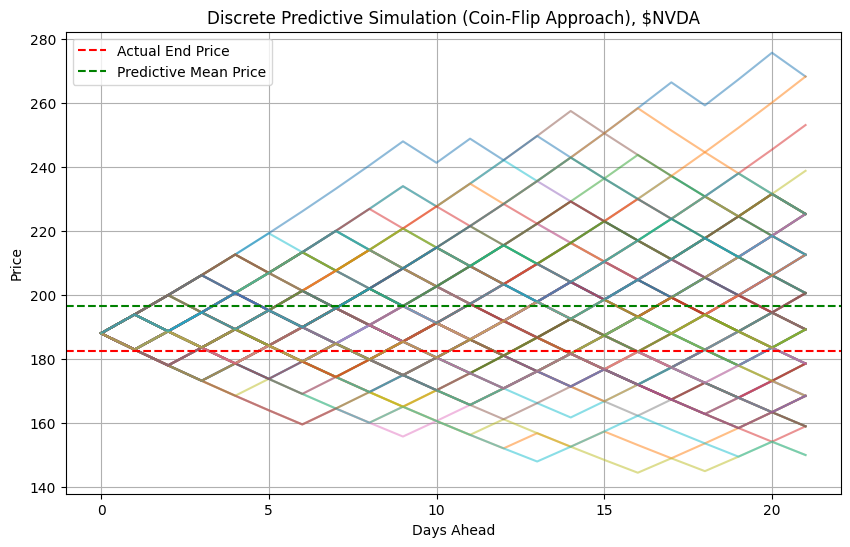

---------------------------------------------
$SPY Results
Training Window: 2014-02-01 → 2024-03-01
Prediction Window: 2025-11-06 → 2025-12-06
Trading Days Simulated: 21
---------------------------------------------
Starting Price:           670.31
Actual Price on End Date: 685.69
Simulated Mean Price:     677.32
Simulated Median Price:   683.93
95% Confidence Interval:  (612.47, 747.06)
---------------------------------------------


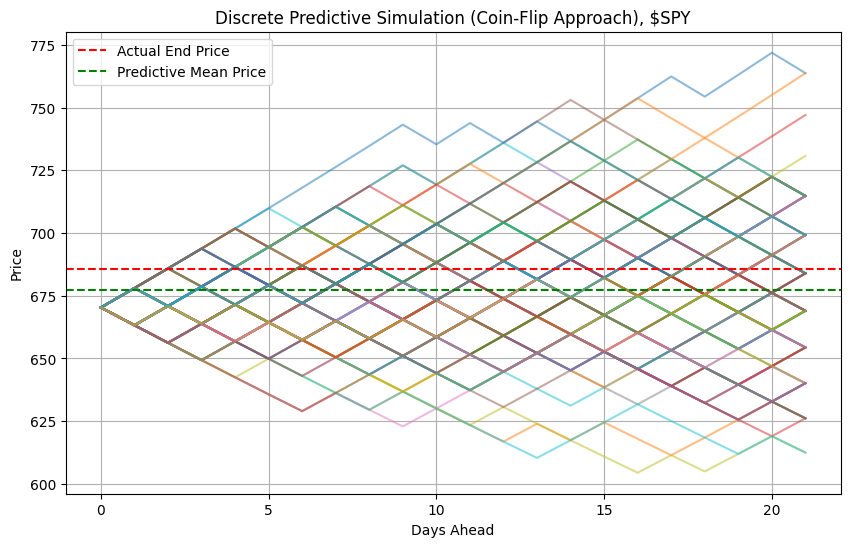

---------------------------------------------
$^DJI Results
Training Window: 2014-02-01 → 2024-03-01
Prediction Window: 2025-11-06 → 2025-12-06
Trading Days Simulated: 21
---------------------------------------------
Starting Price:           46912.30
Actual Price on End Date: 47954.99
Simulated Mean Price:     47277.20
Simulated Median Price:   47738.15
95% Confidence Interval:  (42759.11, 52135.68)
---------------------------------------------


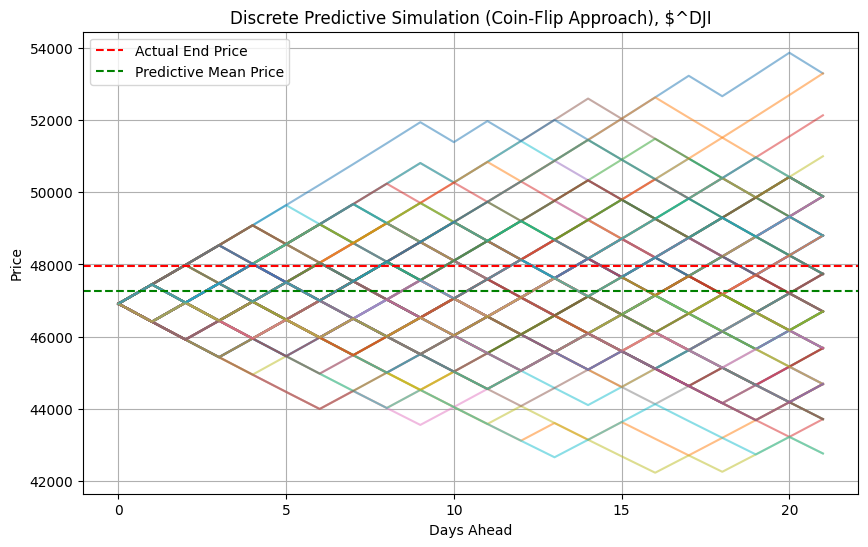

---------------------------------------------
$WMT Results
Training Window: 2014-02-01 → 2024-03-01
Prediction Window: 2025-11-06 → 2025-12-06
Trading Days Simulated: 21
---------------------------------------------
Starting Price:           101.68
Actual Price on End Date: 115.11
Simulated Mean Price:     102.61
Simulated Median Price:   103.77
95% Confidence Interval:  (91.05, 115.21)
---------------------------------------------


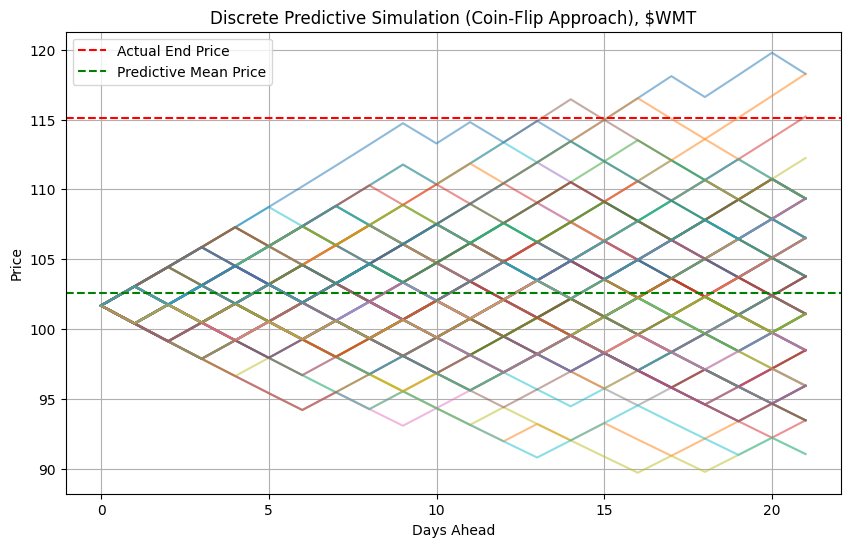

In [68]:
def discrete_coinflip(s0, mu, sigma, days, sims, seed):
    """
    Discrete approach using coin flips:
    X(t+1) = X(t) * (1 + mu ± sigma)
    """
    if seed:
        np.random.seed(seed)

    paths = np.zeros((days + 1, sims))
    paths[0] = s0

    coinflips = np.random.choice([1, -1], size=(days, sims))
    multipliers = 1 + mu + coinflips * sigma
    paths[1:] = s0 * np.cumprod(multipliers, axis=0)

    return paths

for ticker in tickers:
  params = all_params[ticker]
  # Run simulation
  paths = discrete_coinflip(
      s0=params["starting_price"],
      mu=params["mu"],
      sigma=params["sigma"],
      days=params["num_days"],
      sims=params["num_sims"],
      seed=params["seed"]
  )

  final_prices = paths[-1]

  # Compute statistics
  expected_price = np.mean(final_prices)
  median_price = np.median(final_prices)
  ci_95 = np.percentile(final_prices, [2.5, 97.5])
  actual_ending_price = params["predict_data"].iloc[-1]
  print("---------------------------------------------")
  print(f"${params['ticker']} Results")
  print(f"Training Window: {params['train_start']} → {params['train_end']}")
  print(f"Prediction Window: {params['predict_start']} → {params['predict_end']}")
  print(f"Trading Days Simulated: {params['num_days']}")
  print("---------------------------------------------")
  print(f"Starting Price:           {params['starting_price']:.2f}")
  print(f"Actual Price on End Date: {actual_ending_price:.2f}")
  print(f"Simulated Mean Price:     {expected_price:.2f}")
  print(f"Simulated Median Price:   {median_price:.2f}")
  print(f"95% Confidence Interval:  ({ci_95[0]:.2f}, {ci_95[1]:.2f})")
  print("---------------------------------------------")

  # Plot simulation
  plt.figure(figsize=(10, 6))
  for i in range(100):
      plt.plot(paths[:, i], alpha=0.5)

  plt.axhline(actual_ending_price, color='red', linestyle='--', label='Actual End Price')
  plt.axhline(expected_price, color='green', linestyle='--', label='Predictive Mean Price')
  plt.title(f"Discrete Predictive Simulation (Coin-Flip Approach), ${params['ticker']}")
  plt.xlabel("Days Ahead")
  plt.ylabel("Price")
  plt.legend()
  plt.grid(True)
  plt.show()
